# Conditional NF on Toy Data

Conditional Normalizing Flow on Toy Data.

### Imports

In [3]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.special import logit, expit

import matplotlib.pyplot as plt
import corner

import jax
import jax.numpy as jnp
import optax
import equinox as eqx

# FlowJAX (new API)
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import Normal

from pathlib import Path

import seaborn as sns
from tqdm import tqdm, trange

import utils as ut

# silence unnecessary warnings about some specific model not being available (shouldn't hurt performance according to ChatGPT)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [4]:
import os
import socket
print(f"Hostname: {socket.gethostname()}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")
!nvidia-smi

Hostname: kng-cl-nv02.hpc.physik.uni-muenchen.de
CUDA_VISIBLE_DEVICES: 0
Fri Feb 20 21:28:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:D5:00.0 Off |                    0 |
| N/A   38C    P0             64W /  300W |   61525MiB /  81920MiB |      0%      Default |
|                                         |                        

In [5]:
jax.devices()

[CudaDevice(id=0)]

### Generate Data

In [6]:
# let's prepare some fake data: high masses and low redshift -> detected

rng = np.random.default_rng()
m1_detected = rng.normal(loc = 40, scale = 10, size = 50000)
m2_detected = rng.normal(loc = 30, scale = 7.5, size = 50000)
z_detected = rng.normal(loc = 0.3, scale = 0.1, size = 50000)
far_min_detected = rng.uniform(low = 1e-10, high = 1, size = 50000)
m1_not_detected = rng.normal(loc = 10, scale = 6, size = 50000)
m2_not_detected = rng.normal(loc = 6, scale = 2.5, size = 50000)
z_not_detected = rng.normal(loc = 1, scale = 0.2, size = 50000)
far_min_not_detected = rng.uniform(low = 1, high = 100, size = 50000)

detected = np.array([True]*50000 + [False]*50000) # only for selection purpose later, does not show up in training or anywhere else

data_dict = {
    "m1": np.append(m1_detected, m1_not_detected),
    "m2": np.append(m2_detected, m2_not_detected),
    "z": np.append(z_detected, z_not_detected),
    "far_min": np.append(far_min_detected, far_min_not_detected),
    "detected": detected,
}
data_df = pd.DataFrame(data_dict)

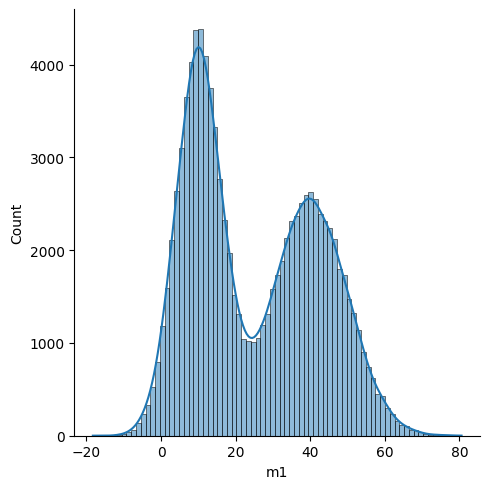

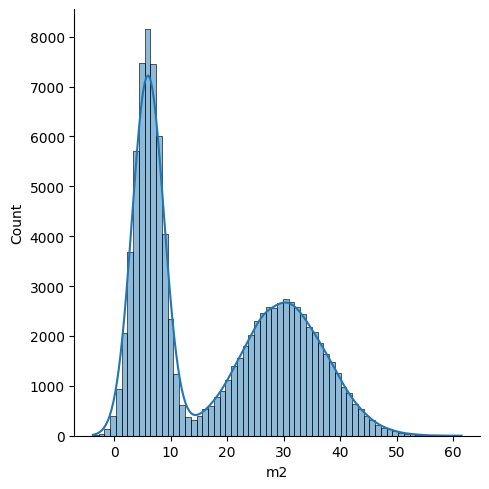

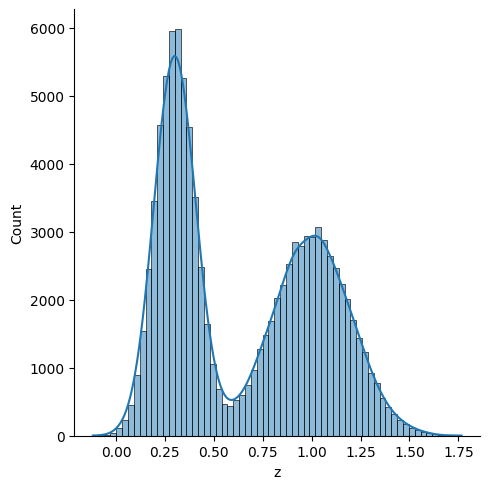

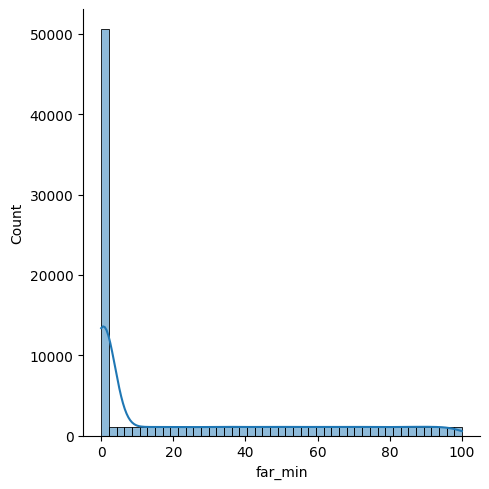

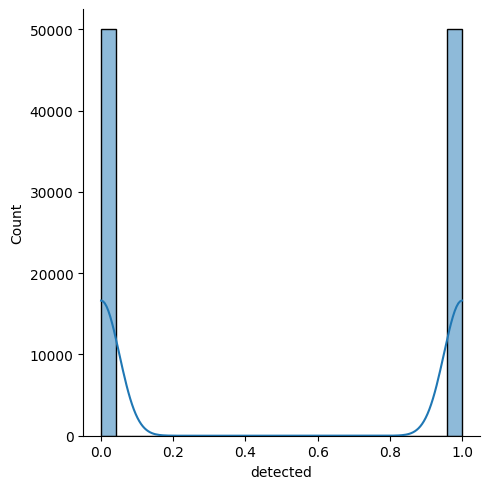

In [7]:
for col in data_df.columns:
    sns.displot(data_df[col], kde = True)
    plt.show()

### Prepare the data

FORWARD / INVERSE TRANSFORMS + WHITENING

In [9]:
X_data = ut.Data(pd.DataFrame(data_df["far_min"]))
conditioning_data = ut.Data(data_df, cols = ["m1", "m2", "z"])
dataset = ut.Dataset(X = X_data, y = conditioning_data, use_whitened_X=True, use_whitened_y = True)

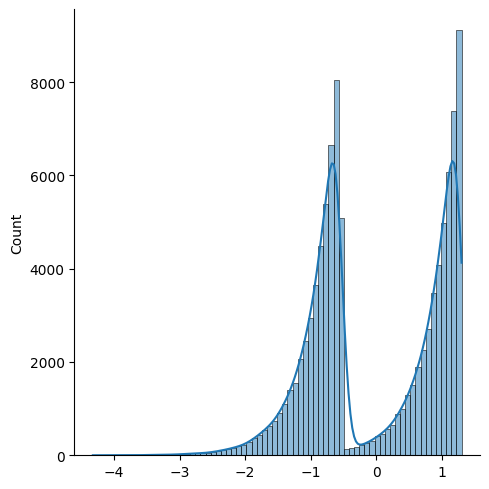

In [10]:
for i in range(dataset.X_data.whitened_data.shape[1]):

    sns.displot(np.array(dataset.X[:, i]), kde=True)
    plt.show()

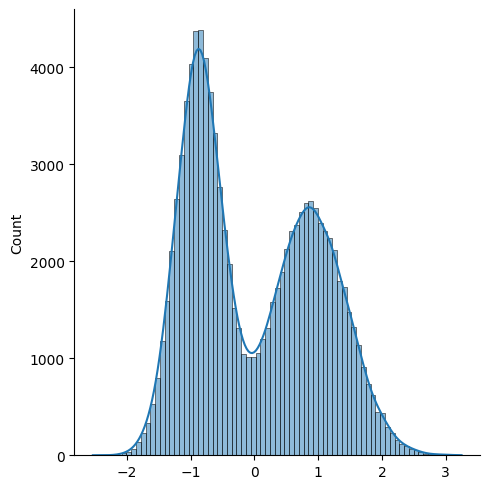

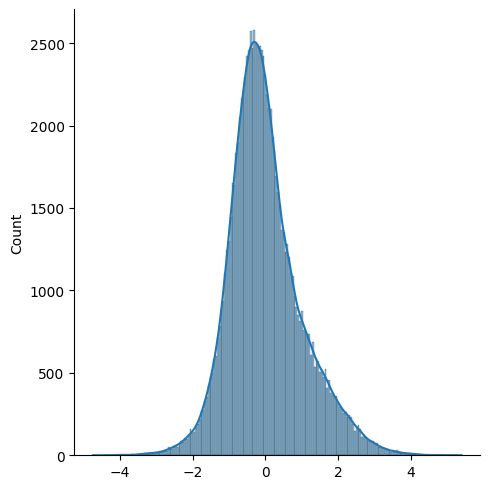

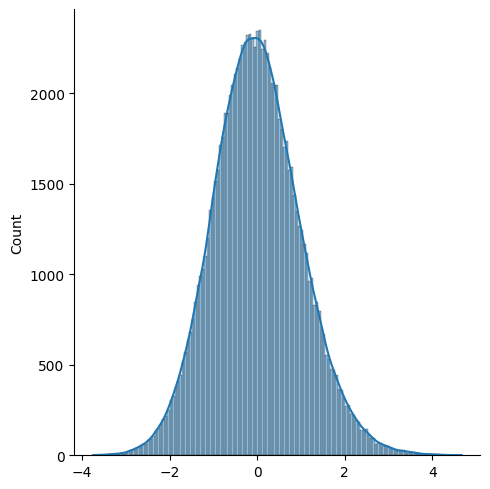

In [11]:
for i in range(dataset.y_data.whitened_data.shape[1]):

    sns.displot(np.array(dataset.y[:, i]), kde=True)
    plt.show()

### Build Flowjax MAF

In [13]:
key_val = 0
key = jax.random.key(key_val)

train_dataset, val_dataset, train_idx, val_idx = dataset.split(key, train_frac=0.8)

config_MAF = {
    "base_dist": "Normal",
    "data_dim": train_dataset.X.shape[1],
    "key": key_val,
    "cond_dim": train_dataset.y.shape[1],  
    "flow_layers": 6,
    "nn_width": 96,
    "nn_depth": 4
}

config = config_MAF
config["type"] = "MAF"

flow = ut.create_flow_from_config(config)

### Training Loop

In [14]:
flow, meta = ut.train_flow(flow, train_dataset, val_dataset, patience = 25, batch_size = 4096)

Training:   6%|▌         | 61/1000 [00:13<03:33,  4.41it/s, best_val=0.4374, patience=-1, train=0.4326, val=0.4520] 


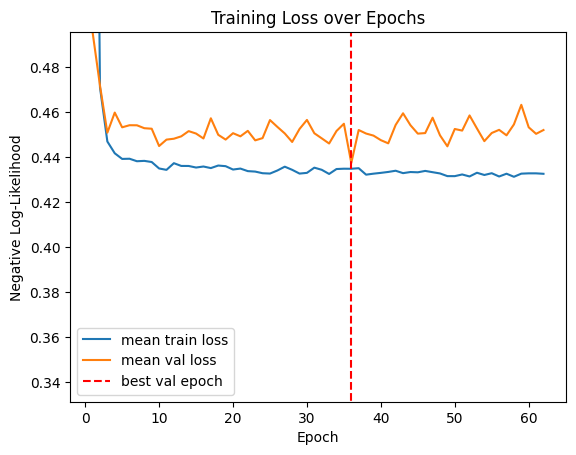

In [15]:
train_losses = meta["train_losses"]
val_losses = meta["val_losses"]

sns.lineplot(x=np.arange(1, len(train_losses) + 1), y=train_losses, label = "mean train loss")
sns.lineplot(x=np.arange(1, len(val_losses) + 1), y=val_losses, label = "mean val loss")
plt.vlines(x = meta["best_epoch"], ymin = min(val_losses)-1, ymax = max(val_losses), color = "red", linestyle = "--", label = "best val epoch")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss over Epochs")
# plt.yscale("log")
plt.ylim(min(val_losses + train_losses)-.1, max(val_losses))
plt.show()

In [28]:
cond = conditioning_data.whitened_data
S = 100
# 4. sample in whitened x-space
z_key, key = jax.random.split(key)
x_white_samples = flow.sample(z_key, (S,), condition=cond)  # (S, dx)

print(x_white_samples.shape, cond.shape)
x_mean_samples = np.array(x_white_samples.mean(axis = 0))
x_std_samples = np.array(x_white_samples.std(axis = 0))
print(x_mean_samples.shape), print(x_std_samples.shape)

# 5. map samples back to original x-space
x_samples_orig_space = dataset.to_original_space_X(x_mean_samples)
# x_std_samples_orig_space = np.array(x_white_samples.std(axis = 0))
x_std_samples_orig_space = []
for x_ii_samples in x_white_samples:
    x_std_samples_orig_space.append(dataset.to_original_space_X(x_ii_samples))
x_std_samples_orig_space = np.array(x_std_samples_orig_space).std(axis = 0)

(100, 100000, 1) (100000, 3)
(100000, 1)
(100000, 1)


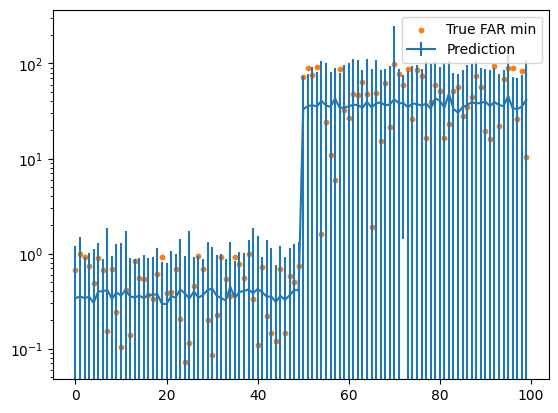

In [37]:
plot_jump = 1000
plt.scatter(range(len(dataset.y_data[::plot_jump])), dataset.X_data.samples[::plot_jump], s = 10, c = "tab:orange", label = "True FAR min")
plt.errorbar(x = range(len(dataset.y_data[::plot_jump])), y = x_samples_orig_space[:, 0][::plot_jump], yerr = x_std_samples_orig_space[:, 0][::plot_jump], label = "Prediction")
# plt.scatter(x = range(len(dataset.y_data[::plot_jump])), y = x_samples_orig_space[:, 0][::plot_jump], label = "Prediction")

plt.legend()
plt.yscale("log")
plt.show()

In [33]:
probs = flow.log_prob(x = X_data.whitened_data, condition = cond)

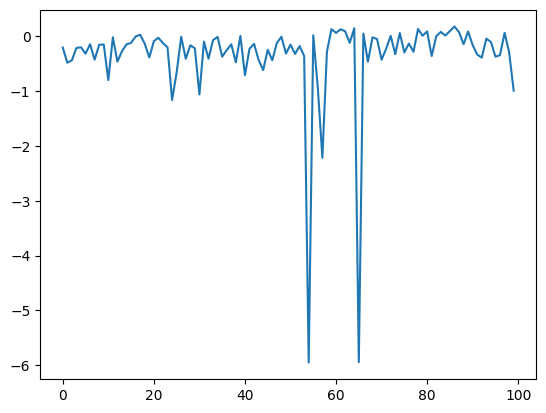

In [36]:
plt.plot(probs[::plot_jump])